In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# Load Kaggle competition dataset (with fallback to local dataset)
try:
    import kagglehub
    path = kagglehub.competition_download("house-prices-advanced-regression-techniques")
    train_df = pd.read_csv(os.path.join(path, "train.csv"))
    print("Loaded dataset from Kaggle API!")
except Exception as e:
    print(f"Kaggle Download Notice: {e}")
    print("Loading local dataset fallback...")
    train_df = pd.read_csv("data/train.csv")

print(f"Train dataset shape: {train_df.shape}")
train_df.head()

c:\Users\91848\Desktop\advance-regression\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded dataset from Kaggle API!
Train dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
df = train_df.copy()

In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum().sort_values()

Id                0
MSSubClass        0
MSZoning          0
LotArea           0
LotShape          0
               ... 
MasVnrType      872
Fence          1179
Alley          1369
MiscFeature    1406
PoolQC         1453
Length: 81, dtype: int64

In [9]:
def missing_values(df):
  nan_values = df.isnull().sum()
  nan_values = nan_values[nan_values>0].sort_values()
  return nan_values

In [10]:
nan_values = missing_values(df)
nan_values

Electrical         1
MasVnrArea         8
BsmtCond          37
BsmtFinType1      37
BsmtQual          37
BsmtExposure      38
BsmtFinType2      38
GarageType        81
GarageQual        81
GarageFinish      81
GarageCond        81
GarageYrBlt       81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [11]:
nan_percent = (100 *(nan_values/len(df)))
nan_percent

Electrical       0.068493
MasVnrArea       0.547945
BsmtCond         2.534247
BsmtFinType1     2.534247
BsmtQual         2.534247
BsmtExposure     2.602740
BsmtFinType2     2.602740
GarageType       5.547945
GarageQual       5.547945
GarageFinish     5.547945
GarageCond       5.547945
GarageYrBlt      5.547945
LotFrontage     17.739726
FireplaceQu     47.260274
MasVnrType      59.726027
Fence           80.753425
Alley           93.767123
MiscFeature     96.301370
PoolQC          99.520548
dtype: float64

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\1179626544.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

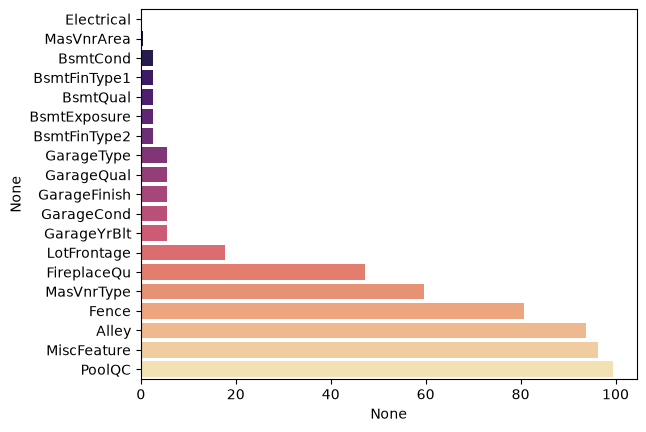

In [12]:
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [13]:
df['Electrical'].isnull().sum()

np.int64(1)

In [14]:
df['Electrical']

0       SBrkr
1       SBrkr
2       SBrkr
3       SBrkr
4       SBrkr
        ...  
1455    SBrkr
1456    SBrkr
1457    SBrkr
1458    FuseA
1459    SBrkr
Name: Electrical, Length: 1460, dtype: str

In [15]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [16]:
df['Electrical'].isnull().sum()

np.int64(0)

In [17]:
df['MasVnrArea'].value_counts()

MasVnrArea
0.0      861
180.0      8
108.0      8
72.0       8
120.0      7
        ... 
426.0      1
96.0       1
438.0      1
194.0      1
119.0      1
Name: count, Length: 327, dtype: int64

In [18]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [19]:
df['MasVnrArea']

0       196.0
1         0.0
2       162.0
3         0.0
4       350.0
        ...  
1455      0.0
1456    119.0
1457      0.0
1458      0.0
1459      0.0
Name: MasVnrArea, Length: 1460, dtype: float64

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\2093647144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

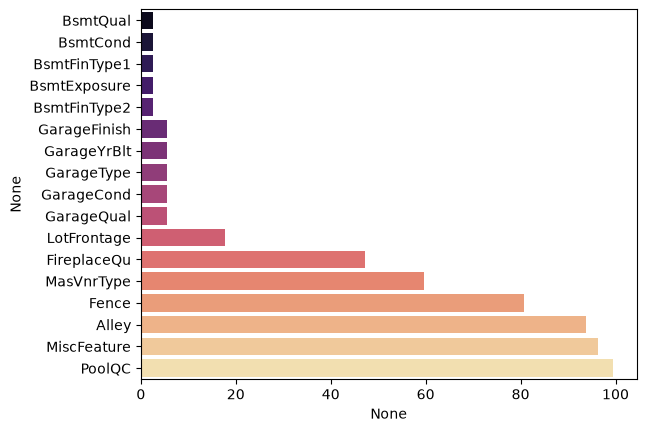

In [20]:
nan_values = missing_values(df)
nan_percent = (100 *(nan_values/len(df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [21]:
df[['BsmtQual','BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']]

,BsmtQual,BsmtCond,BsmtFinType1,BsmtExposure,BsmtFinType2
0,Gd,TA,GLQ,No,Unf
1,Gd,TA,ALQ,Gd,Unf
2,Gd,TA,GLQ,Mn,Unf
3,TA,Gd,ALQ,No,Unf
4,Gd,TA,GLQ,Av,Unf
...,...,...,...,...,...
1455,Gd,TA,Unf,No,Unf
1456,Gd,TA,ALQ,No,Rec
1457,TA,Gd,GLQ,No,Unf
1458,TA,TA,GLQ,Mn,Rec


In [22]:
bsm = ['BsmtQual','BsmtCond', 'BsmtFinType1', 'BsmtExposure', 'BsmtFinType2']
for i in bsm:
  print(type(i))

<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>
<class 'str'>


In [23]:
df[bsm] = df[bsm].fillna('None')

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\2093647144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

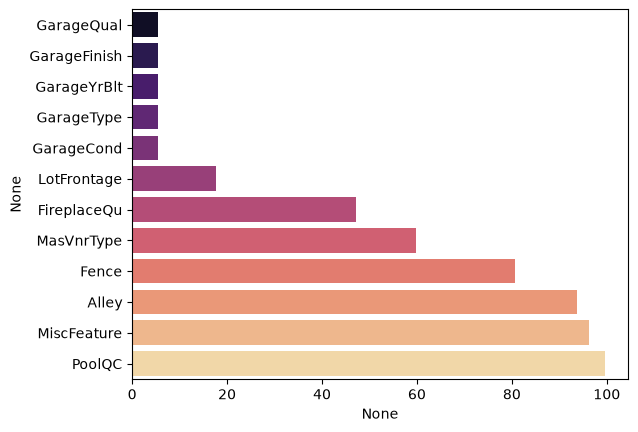

In [24]:
nan_values = missing_values(df)
nan_percent = (100 *(nan_values/len(df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [25]:
nan_values

GarageQual        81
GarageFinish      81
GarageYrBlt       81
GarageType        81
GarageCond        81
LotFrontage      259
FireplaceQu      690
MasVnrType       872
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [26]:
df[['GarageQual', 'GarageFinish', 'GarageYrBlt', 'GarageType', 'GarageCond']]

,GarageQual,GarageFinish,GarageYrBlt,GarageType,GarageCond
0,TA,RFn,2003.0,Attchd,TA
1,TA,RFn,1976.0,Attchd,TA
2,TA,RFn,2001.0,Attchd,TA
3,TA,Unf,1998.0,Detchd,TA
4,TA,RFn,2000.0,Attchd,TA
...,...,...,...,...,...
1455,TA,RFn,1999.0,Attchd,TA
1456,TA,Unf,1978.0,Attchd,TA
1457,TA,RFn,1941.0,Attchd,TA
1458,TA,Unf,1950.0,Attchd,TA


In [27]:
garage = ['GarageQual', 'GarageFinish', 'GarageType', 'GarageCond']
df[garage] = df[garage].fillna('None')

In [28]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].mean())

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\2093647144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

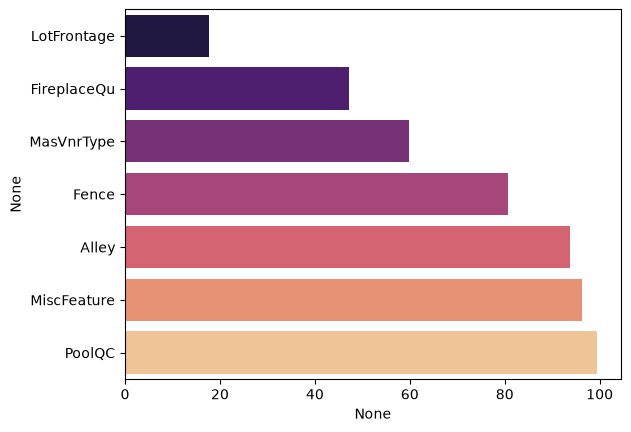

In [29]:
nan_values = missing_values(df)
nan_percent = (100 *(nan_values/len(df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [30]:
df['LotFrontage']

0       65.0
1       80.0
2       68.0
3       60.0
4       84.0
        ... 
1455    62.0
1456    85.0
1457    66.0
1458    68.0
1459    75.0
Name: LotFrontage, Length: 1460, dtype: float64

<Axes: ylabel='LotFrontage'>

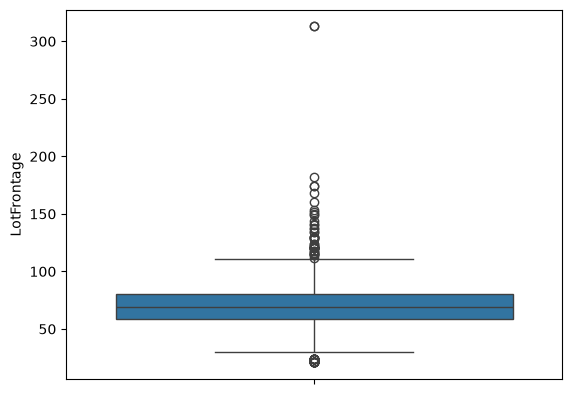

In [31]:
sns.boxplot( y = 'LotFrontage', data= df)

In [32]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\2093647144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

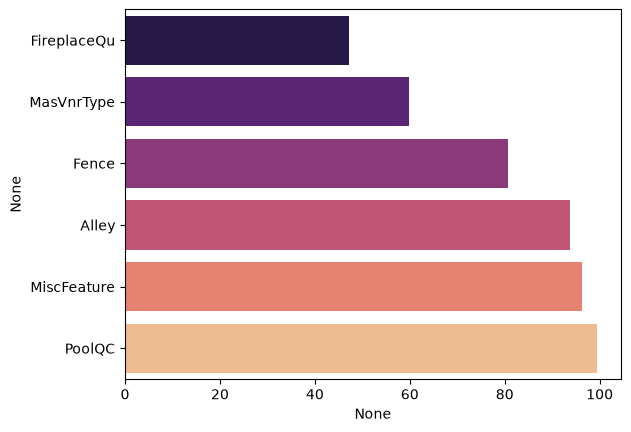

In [33]:
nan_values = missing_values(df)
nan_percent = (100 *(nan_values/len(df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [34]:
df['FireplaceQu']

0       NaN
1        TA
2        TA
3        Gd
4        TA
       ... 
1455     TA
1456     TA
1457     Gd
1458    NaN
1459    NaN
Name: FireplaceQu, Length: 1460, dtype: str

In [35]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('None')

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\2093647144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

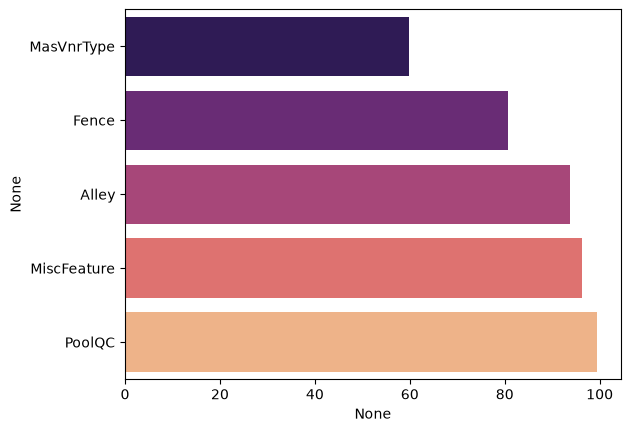

In [36]:
nan_values = missing_values(df)
nan_percent = (100 *(nan_values/len(df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [37]:
df['MasVnrType']

0       BrkFace
1           NaN
2       BrkFace
3           NaN
4       BrkFace
         ...   
1455        NaN
1456      Stone
1457        NaN
1458        NaN
1459        NaN
Name: MasVnrType, Length: 1460, dtype: str

In [38]:
df['MasVnrType'] = df['MasVnrType'].fillna('None')

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\2093647144.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')


<Axes: xlabel='None', ylabel='None'>

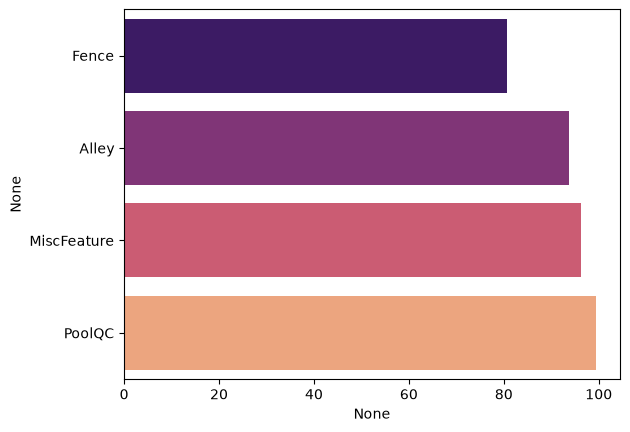

In [39]:
nan_values = missing_values(df)
nan_percent = (100 *(nan_values/len(df)))
sns.barplot(x = nan_percent, y = nan_percent.index, palette = 'magma')

In [40]:
df = df.drop(['Fence', 'Alley', 'MiscFeature', 'PoolQC'], axis = 1)

In [41]:
nan_values = missing_values(df)
nan_values

Series([], dtype: int64)

In [42]:
df.isnull().sum().any()

np.False_

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

## Outlier removal

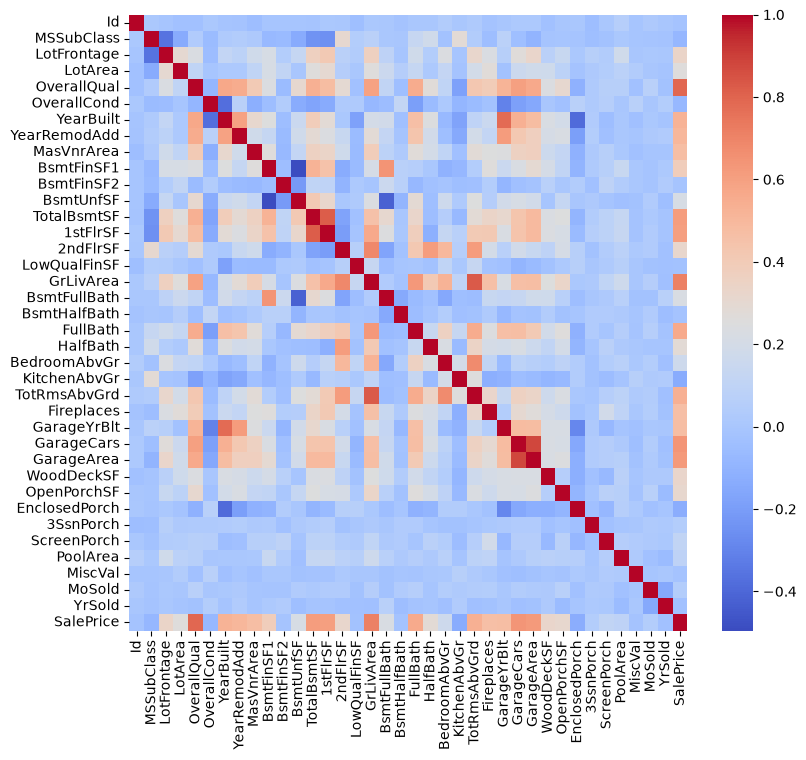

In [44]:
corr = df.corr(numeric_only= True)
plt.figure(figsize = (9,8))
sns.heatmap(corr, annot = False, cmap='coolwarm')
plt.show()

In [45]:
df.corr(numeric_only= True)['SalePrice'].sort_values()

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.334771
BsmtFinSF1       0.386420
Fireplaces       0.466929
GarageYrBlt      0.470177
MasVnrArea       0.472614
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

In [46]:
outlier_cols = ['OverallQual','GrLivArea','GarageCars','GarageArea']

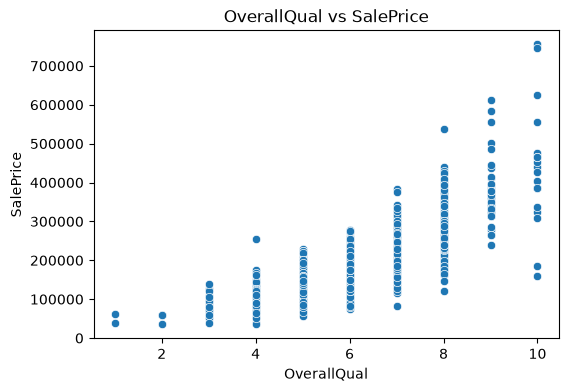

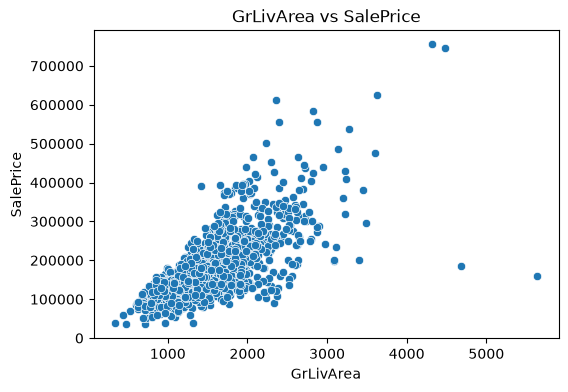

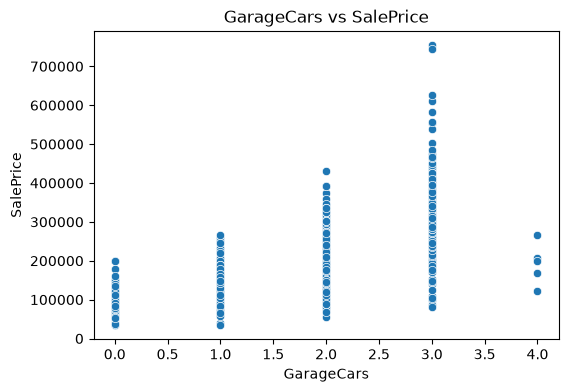

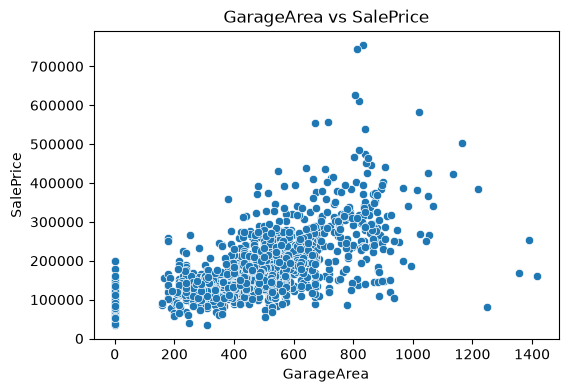

In [47]:
for col in outlier_cols:
  plt.figure(figsize= (6,4))
  sns.scatterplot(x = df[col],y =  df['SalePrice'], data= df)
  plt.xlabel(col)
  plt.ylabel('SalePrice')
  plt.title(f'{col} vs SalePrice')
  plt.show()

In [48]:
for col in outlier_cols:
  Q1 = df[col].quantile(0.25) # type: ignore
  Q3 = df[col].quantile(0.75) # type: ignore

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df = df[(df[col] >= lower) & (df[col] <= upper)] # type: ignore

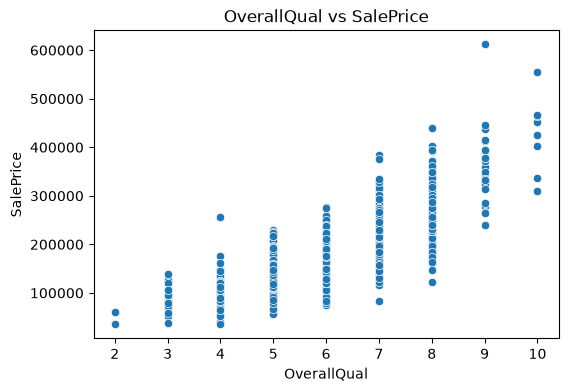

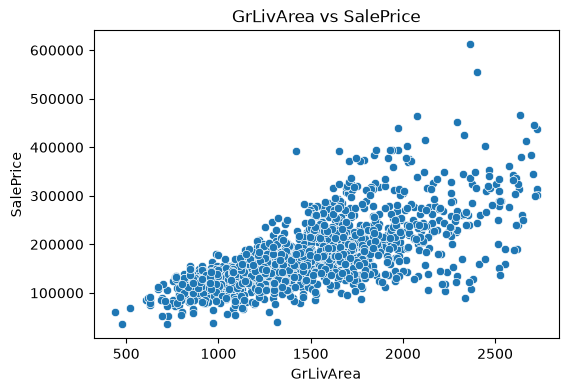

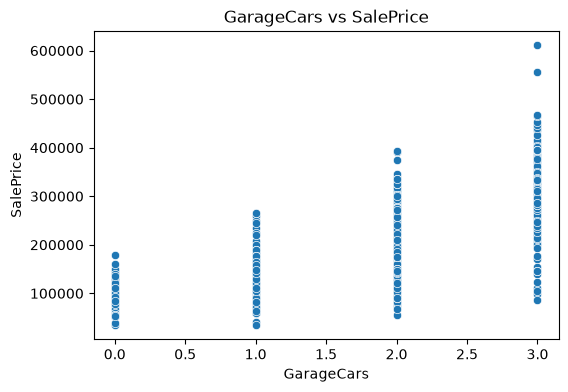

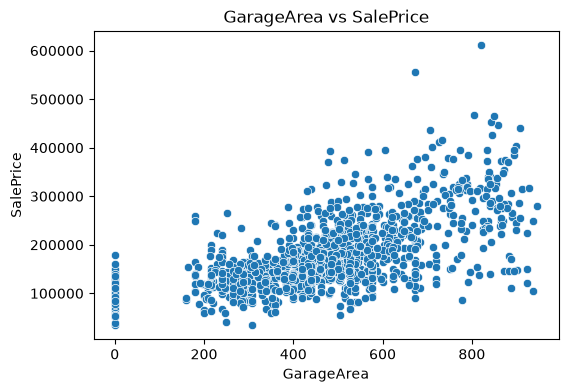

In [49]:
for col in outlier_cols:
  plt.figure(figsize= (6,4))
  sns.scatterplot(x = df[col],y =  df['SalePrice'], data= df)
  plt.xlabel(col)
  plt.ylabel('SalePrice')
  plt.title(f'{col} vs SalePrice')
  plt.show()

In [50]:
df.corr(numeric_only=True)['SalePrice'].sort_values()

EnclosedPorch   -0.172355
KitchenAbvGr    -0.147908
OverallCond     -0.102577
MSSubClass      -0.099109
LowQualFinSF    -0.081653
Id              -0.035927
BsmtHalfBath    -0.028946
YrSold          -0.026767
MiscVal         -0.021694
BsmtFinSF2       0.003187
PoolArea         0.025021
3SsnPorch        0.060992
MoSold           0.070813
ScreenPorch      0.087306
BedroomAbvGr     0.129826
BsmtUnfSF        0.191871
2ndFlrSF         0.237616
LotArea          0.254532
BsmtFullBath     0.254841
HalfBath         0.272178
WoodDeckSF       0.320387
OpenPorchSF      0.324282
LotFrontage      0.339220
BsmtFinSF1       0.407424
MasVnrArea       0.420433
Fireplaces       0.467195
TotRmsAbvGrd     0.489597
GarageYrBlt      0.498778
YearRemodAdd     0.532393
FullBath         0.535168
YearBuilt        0.581934
1stFlrSF         0.604058
GarageArea       0.634576
TotalBsmtSF      0.638223
GarageCars       0.658031
GrLivArea        0.691931
OverallQual      0.802384
SalePrice        1.000000
Name: SalePr

In [51]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 1408 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1408 non-null   int64  
 1   MSSubClass     1408 non-null   int64  
 2   MSZoning       1408 non-null   str    
 3   LotFrontage    1408 non-null   float64
 4   LotArea        1408 non-null   int64  
 5   Street         1408 non-null   str    
 6   LotShape       1408 non-null   str    
 7   LandContour    1408 non-null   str    
 8   Utilities      1408 non-null   str    
 9   LotConfig      1408 non-null   str    
 10  LandSlope      1408 non-null   str    
 11  Neighborhood   1408 non-null   str    
 12  Condition1     1408 non-null   str    
 13  Condition2     1408 non-null   str    
 14  BldgType       1408 non-null   str    
 15  HouseStyle     1408 non-null   str    
 16  OverallQual    1408 non-null   int64  
 17  OverallCond    1408 non-null   int64  
 18  YearBuilt      1408 non-

In [53]:
df = df.drop('Id', axis = 1)

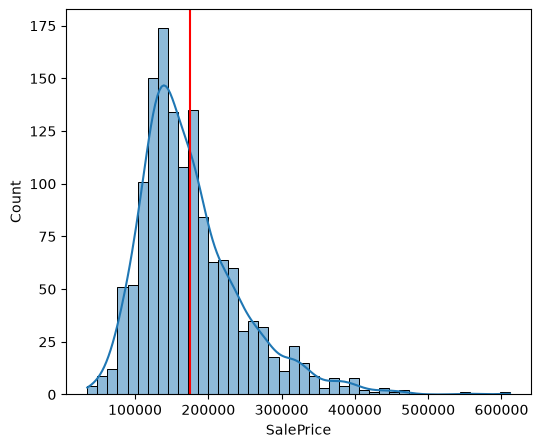

In [54]:
plt.figure(figsize = (6,5))
sns.histplot(df['SalePrice'], kde = True)
plt.axvline(x = (df['SalePrice'].mean()), color = 'r')

In [55]:
df['SalePrice'] = np.log1p(df['SalePrice'])

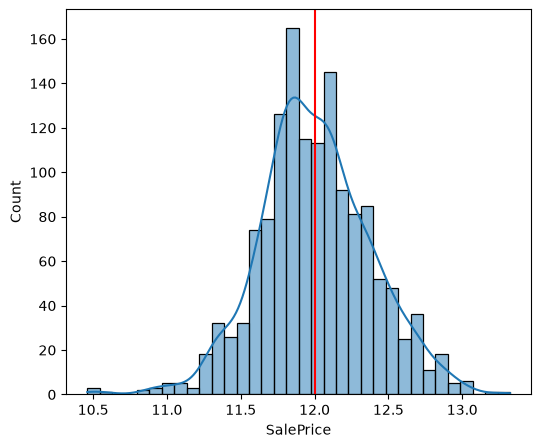

In [56]:
plt.figure(figsize = (6,5))
sns.histplot(df['SalePrice'], kde = True)
plt.axvline(x = (df['SalePrice'].mean()), color = 'r')

### Linear Regression

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [58]:
X = df.drop(['SalePrice'], axis = 1)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [72]:
X_train.shape

(1126, 75)

In [73]:
X_test.shape

(282, 75)

In [59]:
cat_cols = X_train.select_dtypes(include='object').columns

C:\Users\91848\AppData\Local\Temp\ipykernel_9092\262644557.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include='object').columns


In [60]:
df[cat_cols]

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,SaleType,SaleCondition
0,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,None,Attchd,RFn,TA,TA,Y,WD,Normal
1,RL,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
2,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
3,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Detchd,Unf,TA,TA,Y,WD,Abnorml
4,RL,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,...,Gd,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal
1456,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,...,TA,Min1,TA,Attchd,Unf,TA,TA,Y,WD,Normal
1457,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,...,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,WD,Normal
1458,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal


In [61]:
encoder = OneHotEncoder(
  handle_unknown= 'ignore',
  sparse_output= False  
)
X_train_encoded = encoder.fit_transform(X_train[cat_cols])
X_test_encoded = encoder.transform(X_test[cat_cols])

In [62]:
encoded_cols = encoder.get_feature_names_out(cat_cols)
X_train_encoded = pd.DataFrame(X_train_encoded,columns= encoded_cols, index= X_train.index)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoded_cols, index = X_test.index)

In [74]:
X_train_encoded.shape

(1126, 239)

In [75]:
X_test_encoded.shape

(282, 239)

In [76]:
X_train_num = X_train.drop(columns = cat_cols)
X_test_num = X_test.drop(columns= cat_cols)

In [77]:
X_train_final = pd.concat([X_train_num, X_train_encoded], axis= 1)
X_test_final = pd.concat([X_test_num, X_test_encoded], axis = 1)

In [78]:
X_train_final.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
1385,50,40.0,5436,4,8,1922,2007,0.0,735,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
597,120,53.0,3922,7,5,2006,2007,72.0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1174,70,80.0,16560,6,8,1932,1950,0.0,503,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
48,190,33.0,4456,4,5,1920,2008,0.0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
157,60,92.0,12003,8,5,2009,2010,84.0,0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [79]:
X_train_final.shape

(1126, 275)

In [80]:
X_test_final.shape

(282, 275)

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_train_final)

Project 1: Regression — "Which linear model fits this data?"

Dataset: House Prices – Advanced Regression Techniques (has multicollinearity, outliers, mixed feature types — good for stress-testing model choice)

The core decision you're practicing: Linear vs. Ridge vs. Lasso vs. ElasticNet isn't a random pick — it depends on what's wrong with your features:

Lots of correlated features (multicollinearity)? → Ridge (L2 shrinks correlated coefficients together instead of arbitrarily picking one)
Suspect many features are irrelevant, want automatic selection? → Lasso (L1 zeroes out coefficients)
Correlated features AND want sparsity? → ElasticNet (compromise — Lasso alone behaves erratically with correlated features, picking one arbitrarily)
Clean, well-behaved features, no leakage worries? → Plain Linear Regression as your baseline, always

Fundamentals that naturally show up here:

Check multicollinearity first (VIF or correlation heatmap) — this is why you'd choose Ridge over plain linear
Feature engineering: log-transform skewed target/features (house prices are right-skewed)
Cross-validation to pick the regularization strength (alpha) — you can't just eyeball it
Data leakage risk: any feature that encodes info from after the sale (e.g., "days on market" in some versions)

Metric decision:

RMSE if large errors are disproportionately bad (common in pricing — a $200k miss matters more than 2x a $100k miss)
MAE if you want something robust to outliers and easy to explain to non-technical stakeholders
Try both, and explicitly justify to yourself why RMSE vs MAE tells a different story on this specific data (RMSE will be more sensitive to the few really expensive houses)

Deliverable: notebook where you compare all four models with CV, show which regularization strength was chosen and why, and write 3-4 sentences justifying your final metric choice for this use case.
